<img align="left" src="https://www.taborelec.com/Pictures/logo.png">

# real SVM test


this script showes the SVM decision process. four different gaussian phase pulse are transmitted at the generator side while ADC channel 1 capture each frmae. the phase of each captured frame is calculated and plotted. the captured state should be different for each SQP according to SVM configuration

script creates five waves:

DC – represent the quiet IDLE time of the experiment

SQP1 – square gaussian pulse with controlled initial phase = P0. transmiited at the first FRAME_NMB / 4

SQP2 – square gaussian pulse with phase = P0 + 90. transmiited at the second FRAME_NMB / 4

SQP3 – square gaussian pulse with phase = P0 + 180. transmiited at the third FRAME_NMB / 4

SQP4 – square gaussian pulse with phase = P0 + 270. transmiited at the fourth FRAME_NMB / 4


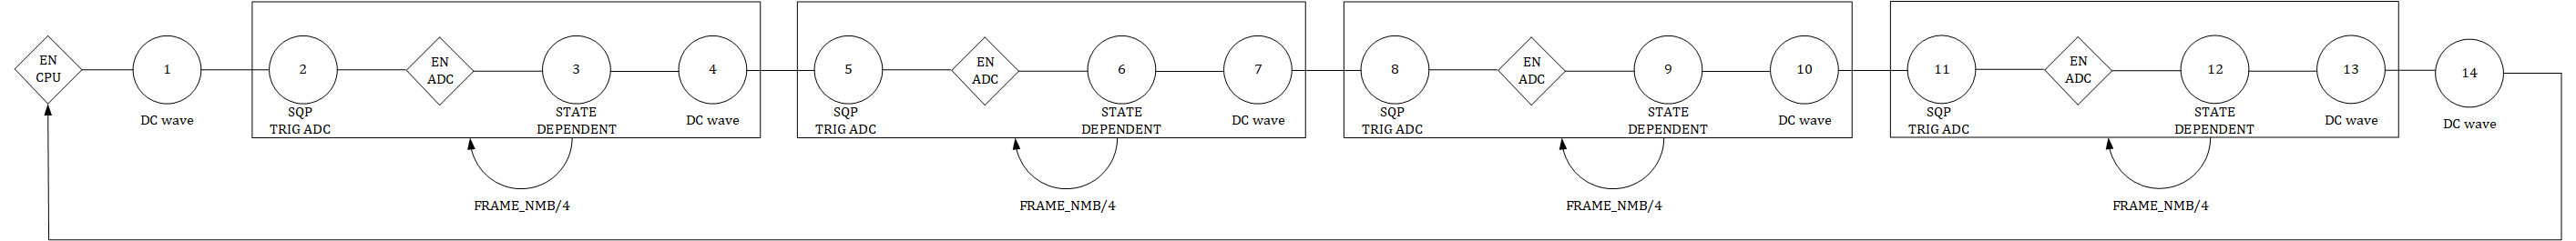
 


All the redout frames are stored in the module memory, but only frame header which contain the integrated values can be read to save time. The script plots the phase and amplitude of each frequency I and Q components.

### Note
This scripts checkes feature of saving only headers by the FPGA instead of headers and frame.


### Input parameters
PW – define all waves length in time. All waves are in the same length

PHASE – the phase of each gaussian pulse

FRAME_NMB - number of frames to capture

P_FREQ - the frequency of the gaussian pulse

DSP_NUM - the DSP entyty that is monitored. values 1-10

MODE - Decision mode. "SVM" or "TH"



In [ ]:
PW = 650e-9
PHASE = 0
FRAME_NMB = 4192000  # 1048000   # 1000 * 4
P_FREQ = 415e6
DSP_NUM = 1
MODE = "SVM"

In [ ]:
import os
import sys
import tempfile
import webbrowser
srcpath = os.path.realpath('../../SourceFiles')
sys.path.append(srcpath)
from teproteus_functions_v3 import connect
from teproteus_functions_v3 import set_lib_dir_path
from teproteus_functions_v3 import disconnect
from teproteus_functions_v3 import get_cpatured_header
from teproteus_functions_v3 import printProteusHeader
from teproteus_functions_v3 import gauss_env
from teproteus_functions_v3 import iq_kernel
from teproteus_functions_v3 import pack_kernel_data
from teproteus_functions_v3 import convert_sample_to_signed
from teproteus_functions_v3 import convert_binoffset_to_signed
from teproteus_functions_v3 import convertFftRawDataTodBm
from teproteus_functions_v3 import NormalIq

In [ ]:
#matplotlib notebook
import numpy as np
import time
import ipywidgets as widgets
from IPython.core.debugger import set_trace
from scipy.signal import chirp, sweep_poly
import matplotlib.pyplot as plt
from scipy import signal
import math

In [ ]:
# internal parameters

DIG_SCLK = 2500e6
SCLK = DIG_SCLK / 10 * 32
WAVE_TIME = PW
GAUS_PW = PW
GAUS_PHASE = PHASE
DDC_NCO = P_FREQ

ADCFS = 1000
DUC_INTERP = 4
Frame_len = 4 * 3456
DSP_DEC_LEN = 230 # int(Frame_len / 12 - 10)


Debug = False

FRAME_NUM = FRAME_NMB
RDOUT_CH = 1

if ADCFS == 500:
    full_scale = "LOW"
elif ADCFS == 800:
    full_scale = "MED"
else:
    full_scale = "HIGH"

if DUC_INTERP==8:
    INTERP = "X8"
elif DUC_INTERP==4:
    INTERP = "X4"
else:
    INTERP = "NONE"

In [ ]:
# Connect to instrument

pid = os.getpid()
print('process id {0}'.format(pid))

# not setting this command means DLL are taken from SYS32
# set_lib_dir_path(r'C:\Users\Proteus\source\repos\ProteusAwg_Aurora_Internal_Mesh\x64\Debug')
#set_lib_dir_path(r'D:\Projects\ProteusAwg_Anabelle\x64\Debug') 
# for service connection enter instrument IP
# for PXI DLL connection enter the module slot number with Auto=False
# when Auto=True the lowest module will be connected
# inst=connect("4",Auto=False)
inst=connect("192.168.0.119")

# Get the instrument's *IDN
#resp = inst.send_scpi_query('*IDN?')
#print('Connected to: ' + resp)

# Get the model name
resp = inst.send_scpi_query(":SYST:iNF:MODel?")
print("Model: {0}".format(resp))

# Get the FPGA version
resp = inst.send_scpi_query(":SYST:iNF:FPGA:VERSion?")
print("FPGA Version: {0}".format(resp))

# Infer the natural DAC waveform format
if 'P9082' in resp:
    dac_mode = 8
else:
    dac_mode = 16
print("DAC waveform format: {0} bits-per-point".format(dac_mode))


if dac_mode == 16:
    max_dac = 65535
    data_type = np.uint16 
else:
    max_dac = 255
    data_type = np.uint8 
    
half_dac = round(max_dac / 2.0)

if SCLK <= 2500e6:
    task_half_dac = 32768
elif dac_mode == 8:
    task_half_dac = 128
else:
    task_half_dac = 32768

print('task_half_dac = {0}'.format(task_half_dac))

In [ ]:
# Several initializations ..
inst.default_paranoia_level = 2

inst.send_scpi_cmd('*CLS; *RST')
inst.send_scpi_cmd(':FREQ:RAST {0}'.format(2500e6))
inst.send_scpi_cmd(':INT {0}'.format(INTERP))
inst.send_scpi_cmd(':ROSC:SOUR INT')
inst.send_scpi_cmd(':FREQ:RAST {0}'.format(SCLK))

inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':OUTP:VOLT {0}'.format(0.5))
inst.send_scpi_cmd(':INIT:CONT ON')
inst.send_scpi_cmd(':TRAC:DEL:ALL')

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# SQP gaussian square pulse

In [ ]:
fs = SCLK
ts = 1 / fs
fc = 0

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=GAUS_PHASE ,direct=True,direct_lo=P_FREQ, mode=8, SQP=True)
sqp_wave1 = e    
N = sqp_wave1.size

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+90) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=True)
sqp_wave2 = e

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+180) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=True)
sqp_wave3 = e

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+270) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=True)
sqp_wave4 = e

print('gaussian square pulse size = {0}, SCLK perioud = {1} ns'.format(N,ts*1e9))

# create wave

In [ ]:
sqp_wave1 = sqp_wave1 * half_dac
sqp_wave1 = sqp_wave1 + half_dac
sqp_wave1 = np.round(sqp_wave1)
sqp_wave1 = np.clip(sqp_wave1, 0, max_dac)

if dac_mode == 16:
    sqp_wave1 = sqp_wave1.astype(np.uint16)
else:
    sqp_wave1 = sqp_wave1.astype(np.uint8)


sqp_wave2 = sqp_wave2 * half_dac
sqp_wave2 = sqp_wave2 + half_dac
sqp_wave2 = np.round(sqp_wave2)
sqp_wave2 = np.clip(sqp_wave2, 0, max_dac)

if dac_mode == 16:
    sqp_wave2 = sqp_wave2.astype(np.uint16)
else:
    sqp_wave2 = sqp_wave2.astype(np.uint8)


sqp_wave3 = sqp_wave3 * half_dac
sqp_wave3 = sqp_wave3 + half_dac
sqp_wave3 = np.round(sqp_wave3)
sqp_wave3 = np.clip(sqp_wave3, 0, max_dac)

if dac_mode == 16:
    sqp_wave3 = sqp_wave3.astype(np.uint16)
else:
    sqp_wave3 = sqp_wave3.astype(np.uint8)


sqp_wave4 = sqp_wave4 * half_dac
sqp_wave4 = sqp_wave4 + half_dac
sqp_wave4 = np.round(sqp_wave4)
sqp_wave4 = np.clip(sqp_wave4, 0, max_dac)

if dac_mode == 16:
    sqp_wave4 = sqp_wave4.astype(np.uint16)
else:
    sqp_wave4 = sqp_wave4.astype(np.uint8)


# download waveforms

In [ ]:
# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(1) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(1))

inst.write_binary_data(':TRAC:DATA', sqp_wave1)
print('downloaded SQP segment {0} in size of {1} to channel {2}'.format(1,sqp_wave1.size,RDOUT_CH))

# play the first segment ( for debug )
inst.send_scpi_cmd(':SOUR:FUNC:MODE:SEGM 1')
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(2) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(2))

inst.write_binary_data(':TRAC:DATA', sqp_wave2)
print('downloaded SQP segment {0} in size of {1} to channel {2}'.format(2,sqp_wave2.size,RDOUT_CH))

# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(3) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(3))

inst.write_binary_data(':TRAC:DATA', sqp_wave3)
print('downloaded SQP segment {0} in size of {1} to channel {2}'.format(3,sqp_wave3.size,RDOUT_CH))


# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(4) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(4))

inst.write_binary_data(':TRAC:DATA', sqp_wave4)
print('downloaded SQP segment {0} in size of {1} to channel {2}'.format(4,sqp_wave4.size,RDOUT_CH))

# Create a DC wave

this wave is stored in SEG_NMB = 5

In [ ]:
dc_wave = np.zeros(N)
dc_wave = [x + half_dac for x in dc_wave]

if dac_mode == 16:
    dc_wave = np.array(dc_wave, dtype=np.uint16)
else:
    dc_wave = np.array(dc_wave, dtype=np.uint8)



# download it to segment 5 of channel 1
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(5) + str(dc_wave.size))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(5))
print('downloaded DC segment {0} in size of {1} to channel {2}'.format(5,dc_wave.size,RDOUT_CH))

inst.write_binary_data(':TRAC:DATA', dc_wave)

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)


# gaussian pulse

In [ ]:
fs = SCLK
ts = 1 / fs
fc = 0

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=GAUS_PHASE ,direct=True,direct_lo=P_FREQ, mode=8, SQP=False)
gp_wave1 = e    
N = gp_wave1.size

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+90) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=False)
gp_wave2 = e

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+180) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=False)
gp_wave3 = e

e, i, q = gauss_env(GAUS_PW, WAVE_TIME, fs, fc, interp=DUC_INTERP,phase=(GAUS_PHASE+270) ,direct=True,direct_lo=P_FREQ, mode=8, SQP=False)
gp_wave4 = e

print('gaussian pulse size = {0}, SCLK perioud = {1} ns'.format(N,ts*1e9))

gp_wave1 = gp_wave1 * half_dac
gp_wave1 = gp_wave1 + half_dac
gp_wave1 = np.round(gp_wave1)
gp_wave1 = np.clip(gp_wave1, 0, max_dac)

if dac_mode == 16:
    gp_wave1 = gp_wave1.astype(np.uint16)
else:
    gp_wave1 = gp_wave1.astype(np.uint8)


gp_wave2 = gp_wave2 * half_dac
gp_wave2 = gp_wave2 + half_dac
gp_wave2 = np.round(gp_wave2)
gp_wave2 = np.clip(gp_wave2, 0, max_dac)

if dac_mode == 16:
    gp_wave2 = gp_wave2.astype(np.uint16)
else:
    gp_wave2 = gp_wave2.astype(np.uint8)


gp_wave3 = gp_wave3 * half_dac
gp_wave3 = gp_wave3 + half_dac
gp_wave3 = np.round(gp_wave3)
gp_wave3 = np.clip(gp_wave3, 0, max_dac)

if dac_mode == 16:
    gp_wave3 = gp_wave3.astype(np.uint16)
else:
    gp_wave3 = gp_wave3.astype(np.uint8)


gp_wave4 = gp_wave4 * half_dac
gp_wave4 = gp_wave4 + half_dac
gp_wave4 = np.round(gp_wave4)
gp_wave4 = np.clip(gp_wave4, 0, max_dac)

if dac_mode == 16:
    gp_wave4 = gp_wave4.astype(np.uint16)
else:
    gp_wave4 = gp_wave4.astype(np.uint8)

# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(6) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(6))

inst.write_binary_data(':TRAC:DATA', gp_wave1)
print('downloaded GP segment {0} in size of {1} to channel {2}'.format(6,gp_wave1.size,RDOUT_CH))

# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(7) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(7))

inst.write_binary_data(':TRAC:DATA', gp_wave2)
print('downloaded GP segment {0} in size of {1} to channel {2}'.format(7,gp_wave2.size,RDOUT_CH))

# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(8) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(8))

inst.write_binary_data(':TRAC:DATA', gp_wave3)
print('downloaded GP segment {0} in size of {1} to channel {2}'.format(8,gp_wave3.size,RDOUT_CH))


# download it to segment
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TRAC:DEF {0},'.format(9) + str(N))
inst.send_scpi_cmd(':TRAC:SEL {0}'.format(9))

inst.write_binary_data(':TRAC:DATA', gp_wave4)
print('downloaded GP segment {0} in size of {1} to channel {2}'.format(9,gp_wave4.size,RDOUT_CH))

In [ ]:
# N to N decision mode

inst.send_scpi_cmd(":DSP:MODE ONE")
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# Create and download Task table to RDOUT channel

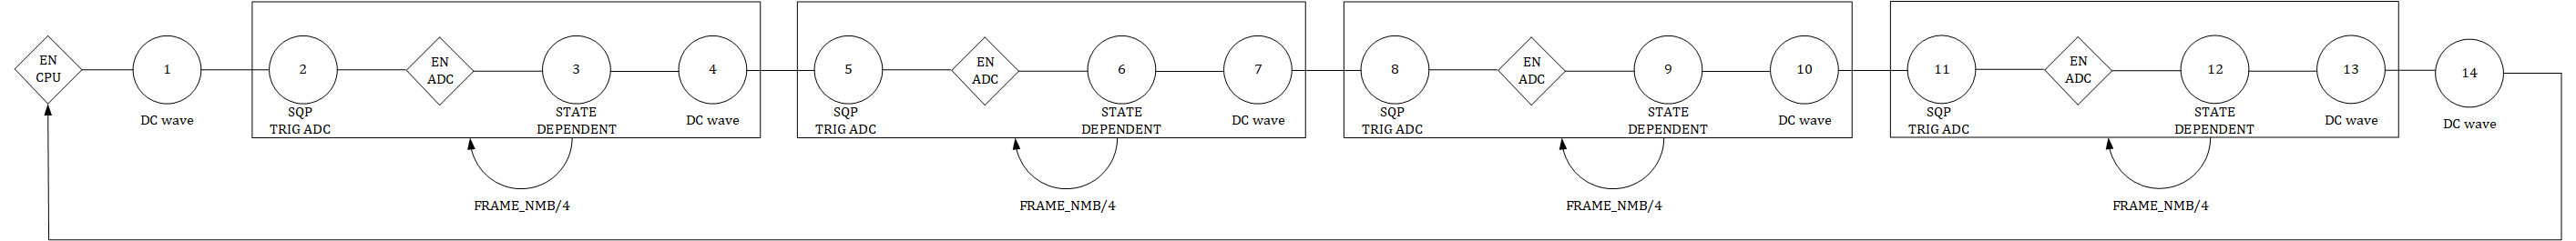

In [ ]:
tasklen = 14

#Select channel
inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':TASK:COMP:LENG {0}'.format(tasklen))

inst.send_scpi_cmd(':TASK:COMP:SEL 1')
inst.send_scpi_cmd(':TASK:COMP:ENAB INT')                            # GLOBAL CPU trigger is the task enable
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:IDLE:LEV {0}'.format(task_half_dac))  # DC level while waiting to a trigger
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(2))                 # the next task is 2

inst.send_scpi_cmd(':TASK:COMP:SEL 2')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(1))                  # play segment 1 SQP
inst.send_scpi_cmd(':TASK:COMP:TYPE STARt')                          # start of sequence
inst.send_scpi_cmd(':TASK:COMP:SEQ {0}'.format(FRAME_NMB//4))        # sequence loop = FRAME_NMB
inst.send_scpi_cmd(':TASK:COMP:IDLE:LEV {0}'.format(task_half_dac))  # DC level while waiting to a trigger
inst.send_scpi_cmd(':TASK:COMP:DTRigger ON')                         # issue a trigger to the ADC at start of segment
inst.send_scpi_cmd(':TASK:COMP:DESTination DSP')                     # Destination is NEXT1.segment of next TASK is according to DSP Decision block.
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(3))                 # the next task is 3

inst.send_scpi_cmd(':TASK:COMP:SEL 3')
inst.send_scpi_cmd(':TASK:COMP:ENAB FBTrg')                          # ADC Feedback trigger
inst.send_scpi_cmd(':TASK:COMP:FBTRigger WAVE')                      # "WAVE" using decision segment. "IDLE" ignoring "DESTination DSP" command and using the TASK segment
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE SEQ')                            # in sequence
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(4))                 # next1 task is 4


inst.send_scpi_cmd(':TASK:COMP:SEL 4')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE END')                            # end of sequence
inst.send_scpi_cmd(':TASK:COMP:LOOP 4')                              # task loop = 32
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(5))                 # next1 task is 5

inst.send_scpi_cmd(':TASK:COMP:SEL 5')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(2))                  # play segment 2 SQP
inst.send_scpi_cmd(':TASK:COMP:TYPE STARt')                          # start of sequence
inst.send_scpi_cmd(':TASK:COMP:SEQ {0}'.format(FRAME_NMB//4))        # sequence loop = FRAME_NMB
inst.send_scpi_cmd(':TASK:COMP:IDLE:LEV {0}'.format(task_half_dac))  # DC level while waiting to a trigger
inst.send_scpi_cmd(':TASK:COMP:DTRigger ON')                         # issue a trigger to the ADC at start of segment
inst.send_scpi_cmd(':TASK:COMP:DESTination DSP')                     # Destination is NEXT1.segment of next TASK is according to DSP Decision block.
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(6))                 # the next task is 6

inst.send_scpi_cmd(':TASK:COMP:SEL 6')
inst.send_scpi_cmd(':TASK:COMP:ENAB FBTrg')                          # ADC Feedback trigger
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE SEQ')                            # in sequence
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(7))                 # next1 task is 7

inst.send_scpi_cmd(':TASK:COMP:SEL 7')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE END')                            # end of sequence
inst.send_scpi_cmd(':TASK:COMP:LOOP 4')                              # task loop = 32
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(8))                 # next1 task is 8

inst.send_scpi_cmd(':TASK:COMP:SEL 8')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(3))                  # play segment 3 SQP
inst.send_scpi_cmd(':TASK:COMP:TYPE STARt')                          # start of sequence
inst.send_scpi_cmd(':TASK:COMP:SEQ {0}'.format(FRAME_NMB//4))        # sequence loop = FRAME_NMB
inst.send_scpi_cmd(':TASK:COMP:IDLE:LEV {0}'.format(task_half_dac))  # DC level while waiting to a trigger
inst.send_scpi_cmd(':TASK:COMP:DTRigger ON')                         # issue a trigger to the ADC at start of segment
inst.send_scpi_cmd(':TASK:COMP:DESTination DSP')                     # Destination is NEXT1.segment of next TASK is according to DSP Decision block.
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(9))                 # the next task is 9

inst.send_scpi_cmd(':TASK:COMP:SEL 9')
inst.send_scpi_cmd(':TASK:COMP:ENAB FBTrg')                          # ADC Feedback trigger
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE SEQ')                            # in sequence
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(10))                # next1 task is 10

inst.send_scpi_cmd(':TASK:COMP:SEL 10')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE END')                            # end of sequence
inst.send_scpi_cmd(':TASK:COMP:LOOP 4')                              # task loop = 32
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(11))                # next1 task is 11

inst.send_scpi_cmd(':TASK:COMP:SEL 11')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(4))                  # play segment 4 SQP
inst.send_scpi_cmd(':TASK:COMP:TYPE STARt')                          # start of sequence
inst.send_scpi_cmd(':TASK:COMP:SEQ {0}'.format(FRAME_NMB//4))        # sequence loop = FRAME_NMB
inst.send_scpi_cmd(':TASK:COMP:IDLE:LEV {0}'.format(task_half_dac))  # DC level while waiting to a trigger
inst.send_scpi_cmd(':TASK:COMP:DTRigger ON')                         # issue a trigger to the ADC at start of segment
inst.send_scpi_cmd(':TASK:COMP:DESTination DSP')                     # Destination is NEXT1.segment of next TASK is according to DSP Decision block.
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(12))                # the next task is 12

inst.send_scpi_cmd(':TASK:COMP:SEL 12')
inst.send_scpi_cmd(':TASK:COMP:ENAB FBTrg')                          # ADC Feedback trigger
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE SEQ')                            # in sequence
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(13))                # next1 task is 13

inst.send_scpi_cmd(':TASK:COMP:SEL 13')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:TYPE END')                            # end of sequence
inst.send_scpi_cmd(':TASK:COMP:LOOP 4')                              # task loop = 32
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(14))                # next1 task is 14



inst.send_scpi_cmd(':TASK:COMP:SEL 14')
inst.send_scpi_cmd(':TASK:COMP:SEGM {0}'.format(5))                  # play segment 5 DC
inst.send_scpi_cmd(':TASK:COMP:NEXT1 {0}'.format(1))                 # the next task is 1


inst.send_scpi_cmd(':TASK:COMP:WRIT')
print('Downloading Task table to channel {0}'.format(RDOUT_CH))

inst.send_scpi_cmd(':INST:CHAN {0}'.format(RDOUT_CH))
inst.send_scpi_cmd(':OUTP ON')
inst.send_scpi_cmd('FUNC:MODE TASK')
inst.send_scpi_cmd('*TRG')

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)


In [ ]:
ret = inst.send_scpi_cmd(':DIG:ACQ:TYPE HEAD')  # ALL / HEADers
print(ret)

In [ ]:
ret = inst.send_scpi_query(':DIG:ACQ:TYPE?')
print(ret)

## Setup Digitizer

In [ ]:
# Setup the digitizer in two-channels mode
inst.send_scpi_cmd(':DIG:MODE DUAL')

# Full scale select
inst.send_scpi_cmd(':DIG:CHAN:RANGe {0}'.format(full_scale)) # { LOW | MEDium | HIGH}

# Set SCLK digitizer 
inst.send_scpi_cmd(':DIG:FREQ {0}'.format(DIG_SCLK))

# Set DDC mode to real
inst.send_scpi_cmd(':DIG:DDC:MODE REAL')

# Set SYNC to SYSREF for phase coherance 
inst.send_scpi_cmd(':DIG:DDC:CLKS AWG')

# Set CH1 input to feed both DDC
inst.send_scpi_cmd(':DIG:DDC:BIND ON')  # ON

# Allocate capture memory according to number of frame and frame length in samples
cmd = ':DIG:ACQuire:FRAM:DEF {0},{1}'.format(FRAME_NUM, Frame_len)
inst.send_scpi_cmd(cmd)
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# Select the frames for the capturing 
capture_first, capture_count = 1, FRAME_NUM
cmd = ":DIG:ACQuire:FRAM:CAPT {0},{1}".format(capture_first, capture_count)
inst.send_scpi_cmd(cmd)

# Enable capturing data from DDR 1
inst.send_scpi_cmd(':DIG:CHAN:SEL 1')
inst.send_scpi_cmd(':DIG:CHAN:STATE ENAB')
# Select the internal-trigger as start-capturing trigger:
inst.send_scpi_cmd(':DIG:TRIG:SOURCE TASK{0}'.format(RDOUT_CH))

# Enable capturing data from DDR 2
inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
inst.send_scpi_cmd(':DIG:CHAN:STATE ENAB')
# Select the internal-trigger as start-capturing trigger:
inst.send_scpi_cmd(':DIG:TRIG:SOURCE TASK{0}'.format(RDOUT_CH))


# Set Trigger AWG delay to 0
inst.send_scpi_cmd(':DIG:TRIG:AWG:TDEL {0}'.format(4e-9))

# Clean memory 
inst.send_scpi_cmd(':DIG:ACQ:ZERO:ALL')

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)
print("Set Digitizer: DUAL mode; ADC Trigger")

resp = inst.send_scpi_query(':DIG:DDC:DEC?')
print(resp)

## Setup DSP

In [ ]:
# Select to store the DSP1 data
inst.send_scpi_cmd(':DSP:STOR DSP')  # DIRect | DSP | FFT
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# dsp decision frame
inst.send_scpi_cmd(':DSP:DEC:FRAM {0}'.format(DSP_DEC_LEN))
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# DSP1 IQ demodulation kernel data
KL = 10240
ki,kq = iq_kernel(fs=DIG_SCLK,flo=DDC_NCO,kl=KL)
mem = pack_kernel_data(ki,kq)

memz = np.zeros(8192)
memz = memz.astype(np.uint32)



inst.send_scpi_cmd(':DSP:IQD:SEL IQ4')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 1) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ5')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 2) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ6')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 3) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ7')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 4) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ8')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 5) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ9')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 6) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ10')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 7) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ11')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 8) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ12')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 9) else memz))
inst.send_scpi_cmd(':DSP:IQD:SEL IQ13')             # DBUG | IQ4 | IQ5 | IQ6 | IQ7 | IQ8 | IQ9 | IQ10 | IQ11 | IQ12 | IQ13
inst.write_binary_data(':DSP:IQD:KER:DATA', (mem if (DSP_NUM == 10) else memz))
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

#define decision DSP path SVM
inst.send_scpi_cmd(':DSP:DEC:IQP:SEL DSP{0}'.format(DSP_NUM))
if MODE == "SVM":
    inst.send_scpi_cmd(':DSP:DEC:IQP:OUTP SVM')
    inst.send_scpi_cmd(':DSP:DEC:IQP:LINE 1,1,0')
    inst.send_scpi_cmd(':DSP:DEC:IQP:LINE 2,-1,0')
    inst.send_scpi_cmd(':DSP:DEC:IQP:LINE 3,0,0')
else:
    inst.send_scpi_cmd(':DSP:DEC:IQP:OUTP THR')
    inst.send_scpi_cmd(':DSP:DEC:IQP:THR:LEVel 0')
    inst.send_scpi_cmd(':DSP:DEC:IQP:THR:INPut Q')

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# map DSP decision path to AWG channel feedback trigger 
inst.send_scpi_cmd(':DSP:DEC:FEEDback:MAPping 0, {0},DEC{1}'.format(RDOUT_CH,DSP_NUM))
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

# segment lookup table according to feedback state
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S1,6'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S2,7'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S3,8'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S4,9'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S5,6'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S6,7'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S7,8'.format(RDOUT_CH))
inst.send_scpi_cmd(':DSP:DEC:FEEDback:CONDition {0},S8,9'.format(RDOUT_CH))
resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)


In [ ]:
inst.send_scpi_cmd(':DSP:DEC:FEEDback:MAPping 0, {0},DEC{1}'.format(0,DSP_NUM))
resp = inst.send_scpi_query(':SYST:ERR?')

inst.send_scpi_cmd(':DIG:FREQ {0}'.format(2700e6))

print(resp)

In [ ]:
# task sync
inst.send_scpi_cmd(':TASK:SYNC')

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)

## Acquire signals into Memory

In [ ]:
# :TRIG:COUPLE ON will require trigger from master to all channel in the master and slaves modules.
# the task trigger "INT" option, is used to listen to this trigger
inst.send_scpi_cmd(':TRIG:COUPLE ON')

# Stop the digitizer's capturing machine (to be on the safe side)
inst.send_scpi_cmd(':DIG:INIT OFF')

# Start the digitizer's capturing machine
inst.send_scpi_cmd(':DIG:INIT ON')
print("Waiting to recive enter to generate trigger - press Enter to start trigger")
input()

inst.send_scpi_cmd('*TRG')

max_iter = 100
frameRx = 0
times = 0
while (frameRx < FRAME_NMB):
    resp = inst.send_scpi_query(':DIG:ACQuire:FRAM:STATus?')
    framesParam = resp.split(",")
    frameRx = int(framesParam[3])
    times += 1
    time.sleep(0.5)
    if times > max_iter:
        break

if (times<max_iter):
    print("Digitizer: Finish Acquisition after {0} iterations".format(times))
else:
    print('Could not finish acquire data- try again')
    
resp = inst.send_scpi_query(':DIG:ACQuire:FRAM:STAT?')
print('captured {0} frames'.format(resp[6:]))
numFramesRx = int(resp[6:])


# time.sleep(30)
# resp = inst.send_scpi_query(':DIG:ACQuire:FRAM:STAT?')
# print(resp)
# print('captured {0} frames'.format(resp[6:]))
# numFramesRx = int(resp[6:])

# Read all captured frame

In [ ]:
# # Choose which frames to read (all in this example)
# inst.send_scpi_cmd(':DIG:DATA:SEL ALL')

# # Choose what to read 
# # (BOTH for frames and headers, FRAM only the frame-data without the header)
# inst.send_scpi_cmd(':DIG:DATA:TYPE FRAM')

# # Get the total data size (in bytes)
# resp = inst.send_scpi_query(':DIG:DATA:SIZE?')
# num_bytes = np.uint32(resp)
# print('Total size in bytes: ' + resp)

# # Read the data that was captured by DDR 1:
# inst.send_scpi_cmd(':DIG:CHAN:SEL 1')
# # because read format is UINT16 we divide byte number by 2
# wavlen = num_bytes // 2
# wav1 = np.zeros(wavlen, dtype=np.uint16)
# rc = inst.read_binary_data(':DIG:DATA:READ?', wav1, num_bytes)
# resp = inst.send_scpi_query(':SYST:ERR?')
# print(resp)
# print("read data from DDR1")

# # Read the data that was captured by DDR 2:
# inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
# # because read format is UINT16 we divide byte number by 2
# wavlen = num_bytes // 2
# wav2 = np.zeros(wavlen, dtype=np.uint16)
# rc = inst.read_binary_data(':DIG:DATA:READ?', wav2, num_bytes)
# resp = inst.send_scpi_query(':SYST:ERR?')
# print(resp)
# print("read data from DDR2")

# Read all frame Headers from Memory

In [ ]:
if DSP_NUM > 5:
    inst.send_scpi_cmd(':DIG:CHAN:SEL 2')
else:
    inst.send_scpi_cmd(':DIG:CHAN:SEL 1')

read = time.time()
# Choose what to read 
inst.send_scpi_cmd(':DIG:DATA:TYPE HEAD')
header_size=88
number_of_frames = numFramesRx
num_bytes = number_of_frames * header_size
print('Total Headers size in bytes: {0} '.format(num_bytes))
header = np.zeros(num_bytes, dtype=np.uint8)
rc = inst.read_binary_data(':DIG:DATA:READ?', header, num_bytes)

resp = inst.send_scpi_query(':SYST:ERR?')
print(resp)
print("read data from DDR")

start = time.time()
print(f'Read time {start - read} \n')
ProteusHeader = get_cpatured_header(printHeader=True,N=number_of_frames,buf=header,dspEn=True)
end = time.time()
print(f'Parser time {end - start}')
    
I_DEC = np.zeros(number_of_frames, dtype=np.int64)
Q_DEC = np.zeros(number_of_frames, dtype=np.int64)
AbsIQ = np.zeros(number_of_frames, dtype=np.float64)
phase = np.zeros(number_of_frames, dtype=np.float64)
STATE = np.zeros(number_of_frames, dtype=np.int32)
N_I_DEC = np.zeros(number_of_frames, dtype=np.float64)
N_Q_DEC = np.zeros(number_of_frames, dtype=np.float64)
N_AbsIQ = np.zeros(number_of_frames, dtype=np.float64)

for i in range(number_of_frames):
    if DSP_NUM == 1:
        I_DEC[i] = ProteusHeader[i].real1_dec
        Q_DEC[i] = ProteusHeader[i].im1_dec
        STATE[i] = ProteusHeader[i].state1
    if DSP_NUM == 2:
        I_DEC[i] = ProteusHeader[i].real2_dec
        Q_DEC[i] = ProteusHeader[i].im2_dec
        STATE[i] = ProteusHeader[i].state2
    if DSP_NUM == 3:
        I_DEC[i] = ProteusHeader[i].real3_dec
        Q_DEC[i] = ProteusHeader[i].im3_dec
        STATE[i] = ProteusHeader[i].state3
    if DSP_NUM == 4:
        I_DEC[i] = ProteusHeader[i].real4_dec
        Q_DEC[i] = ProteusHeader[i].im4_dec
        STATE[i] = ProteusHeader[i].state4
    if DSP_NUM == 5:
        I_DEC[i] = ProteusHeader[i].real5_dec
        Q_DEC[i] = ProteusHeader[i].im5_dec
        STATE[i] = ProteusHeader[i].state5
    if DSP_NUM == 6:
        I_DEC[i] = ProteusHeader[i].real1_dec
        Q_DEC[i] = ProteusHeader[i].im1_dec
        STATE[i] = ProteusHeader[i].state1
    if DSP_NUM == 7:
        I_DEC[i] = ProteusHeader[i].real2_dec
        Q_DEC[i] = ProteusHeader[i].im2_dec
        STATE[i] = ProteusHeader[i].state2
    if DSP_NUM == 8:
        I_DEC[i] = ProteusHeader[i].real3_dec
        Q_DEC[i] = ProteusHeader[i].im3_dec
        STATE[i] = ProteusHeader[i].state3
    if DSP_NUM == 9:
        I_DEC[i] = ProteusHeader[i].real4_dec
        Q_DEC[i] = ProteusHeader[i].im4_dec
        STATE[i] = ProteusHeader[i].state4
    if DSP_NUM == 10:
        I_DEC[i] = ProteusHeader[i].real5_dec
        Q_DEC[i] = ProteusHeader[i].im5_dec
        STATE[i] = ProteusHeader[i].state5

end1 = time.time()
print(f'Decision time {end1 - end}')

for i in range(number_of_frames):    
    AbsIQ[i] = np.sqrt(np.square(Q_DEC[i]) + np.square(I_DEC[i]))
    phase[i] = math.degrees(math.atan2(Q_DEC[i],I_DEC[i]))
    
end2 = time.time()
print(f'Decision time {end2 - end1}')

NI_DEC,NQ_DEC=NormalIq(I_DEC,Q_DEC)
end3 = time.time()
print(f'Normal time {end3 - end2}')

N_AbsIQ = AbsIQ / np.max(AbsIQ)
    

### Save to file for debug

In [ ]:
# np.savetxt('outfile_Only_Header_2.txt', header)
# with open('outfile.txt', 'w') as f:
#     f.write('\n'.join([' '.join(l2) for l2 in ProteusHeader]))


# Plot first frame for each segment

In [ ]:
## This printing is for case only headers read without frames, and we want to know the states
N1=1
N2=FRAME_NMB//4 + 1
N3=FRAME_NMB//2 + 1
N4=FRAME_NMB*3//4 + 1

print('Frame Number {0}, STATE {1}'.format(N1,STATE[N1]))
print('Frame Number {0}, STATE {1}'.format(N2,STATE[N2]))
print('Frame Number {0}, STATE {1}'.format(N3,STATE[N3]))
print('Frame Number {0}, STATE {1}'.format(N4,STATE[N4]))


NUM=1
totlen = Frame_len * NUM
N1=1
if ("BOTH" in inst.send_scpi_query(':DIG:DATA:TYPE?')):  # Query the data read type, if BOTH consider header size
    header_as_points = int(header_size / 2)  # In calculation below we consider points as 2 bytes each
else:
    header_as_points = 0              # if only frames read from Proteus, consider header as 0 size for the calculations

print(f'Header size for calculation is: {header_as_points}')

if DSP_NUM >5:
    wav1_frame = wav2[(N1-1)*(Frame_len + header_as_points):((N1+NUM-1)*(Frame_len + header_as_points) - header_as_points)]
else:
    wav1_frame = wav1[(N1-1)*(Frame_len + header_as_points):((N1+NUM-1)*(Frame_len + header_as_points) - header_as_points)]

N2=FRAME_NMB//4 + 1
if DSP_NUM >5:
    wav2_frame = wav2[(N2-1)*(Frame_len + header_as_points):((N2+NUM-1)*(Frame_len + header_as_points) - header_as_points)]
else:
    wav2_frame = wav1[(N2-1)*(Frame_len + header_as_points):((N2+NUM-1)*(Frame_len + header_as_points) - header_as_points)]

N3=FRAME_NMB//2 + 1
if DSP_NUM >5:
    wav3_frame = wav2[(N3-1)*(Frame_len + header_as_points):((N3+NUM-1)*(Frame_len + header_as_points) - header_as_points)]
else:
    wav3_frame = wav1[(N3-1)*(Frame_len + header_as_points):((N3+NUM-1)*(Frame_len + header_as_points) - header_as_points)]
    
N4=FRAME_NMB*3//4 + 1
if DSP_NUM >5:
    wav4_frame = wav2[(N4-1)*(Frame_len + header_as_points):((N4+NUM-1)*(Frame_len + header_as_points) - header_as_points)]
else:
    wav4_frame = wav1[(N4-1)*(Frame_len + header_as_points):((N4+NUM-1)*(Frame_len + header_as_points) - header_as_points)]

# getting one of the six DSP entities in the captured frame
if DSP_NUM > 5:
    DSPn = DSP_NUM-5
else:
    DSPn = DSP_NUM
    
IQlen = int(totlen/12)
qidx = (DSPn-1)*2
iidx = (DSPn-1)*2+1

wave1_i = np.zeros(IQlen, dtype=np.uint16)
wave1_q = np.zeros(IQlen, dtype=np.uint16)
wave2_i = np.zeros(IQlen, dtype=np.uint16)
wave2_q = np.zeros(IQlen, dtype=np.uint16)
wave3_i = np.zeros(IQlen, dtype=np.uint16)
wave3_q = np.zeros(IQlen, dtype=np.uint16)
wave4_i = np.zeros(IQlen, dtype=np.uint16)
wave4_q = np.zeros(IQlen, dtype=np.uint16)


wave1_q = wav1_frame[qidx::12]
wave1_i = wav1_frame[iidx::12]
wave2_q = wav2_frame[qidx::12]
wave2_i = wav2_frame[iidx::12]
wave3_q = wav3_frame[qidx::12]
wave3_i = wav3_frame[iidx::12]
wave4_q = wav4_frame[qidx::12]
wave4_i = wav4_frame[iidx::12]


# MATH and Decision block are looking on 15 MSB bits
wave1_q = np.floor((wave1_q / 2))
wave1_i = np.floor((wave1_i / 2))
wave2_q = np.floor((wave2_q / 2))
wave2_i = np.floor((wave2_i / 2))
wave3_q = np.floor((wave3_q / 2))
wave3_i = np.floor((wave3_i / 2))
wave4_q = np.floor((wave4_q / 2))
wave4_i = np.floor((wave4_i / 2))

# convert to signed number
wave1_q = convert_binoffset_to_signed(wave1_q,15)
wave1_i = convert_binoffset_to_signed(wave1_i,15)
wave2_q = convert_binoffset_to_signed(wave2_q,15)
wave2_i = convert_binoffset_to_signed(wave2_i,15)
wave3_q = convert_binoffset_to_signed(wave3_q,15)
wave3_i = convert_binoffset_to_signed(wave3_i,15)
wave4_q = convert_binoffset_to_signed(wave4_q,15)
wave4_i = convert_binoffset_to_signed(wave4_i,15)


print("SUM I = {0}".format(np.sum(wave1_i[:DSP_DEC_LEN])))
print("SUM Q = {0}".format(np.sum(wave1_q[:DSP_DEC_LEN])))

print("\n")
printProteusHeader(ProteusHeader,0)

x = range(IQlen)
print(x, len(wave1_i), len(wave1_q))
print(x, len(wave2_i), len(wave2_q))
fig, axs = plt.subplots(1,4)
fig.set_figheight(5)
fig.set_figwidth(20)
axs[0].plot(x, wave1_i, '-',x, wave1_q, '-')  
axs[0].set_title('Frame Number {0}, STATE {1}'.format(N1,STATE[N1]))
axs[1].plot(x, wave2_i, '-',x, wave2_q, '-')  
axs[1].set_title('Frame Number {0}, STATE {1}'.format(N2,STATE[N2]))
axs[2].plot(x, wave3_i, '-',x, wave3_q, '-')  
axs[2].set_title('Frame Number {0}, STATE {1}'.format(N3,STATE[N3]))
axs[3].plot(x, wave4_i, '-',x, wave4_q, '-')  
axs[3].set_title('Frame Number {0}, STATE {1}'.format(N4,STATE[N4]))
plt.show()
del wav1_frame

# Plot Freq Vs Decision  Abs x-y graph 

In [ ]:
f = np.linspace(1, FRAME_NUM, FRAME_NUM, endpoint=True)
fig, axs = plt.subplots(1,4)
fig.set_figheight(5)
fig.set_figwidth(20)
axs[0].plot(NI_DEC, NQ_DEC, '.')
if MODE == "SVM":
    axs[0].plot([1,-1], [1,-1]) # a= 1 , b= 0
    axs[0].plot([1,-1],[-1,1])  # a=-1 , b= 0
    axs[0].plot([1,-1],[0,0])   # a= 0 , b= 0
else:
    axs[0].plot([1,-1],[0,0])   # a= 0 , b= 0

axs[0].set_title('Q vs I')

axs[1].plot(f, N_AbsIQ, '.')
axs[1].set_title('ABS(I,Q)')

axs[2].plot(f, phase, '.')
axs[2].set_title('Phase')

axs[3].plot(f, STATE, '.')
axs[3].set_title('State Decision')

plt.show()


In [ ]:
# close connection
disconnect()